# Kalibracija kamere pomoću OpenCV biblioteke

**Student:** Perica Rajčević  
**Tema:** Kalibracija kamere  
**Alati:** Python, OpenCV, Google Colab

U ovom notebooku implementiram kalibraciju kamere pomoću šahovske ploče.  
Cilj je izračunati matricu kamere i koeficijente distorzije, a onda pomoću njih ispraviti geometrijska izobličenja slike.

## 1. Priprema okruženja

Učitavam potrebne biblioteke i kreiram foldere za podatke i rezultate.

In [ ]:
import os
import glob
import shutil
import urllib.request
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("OpenCV verzija:", cv.__version__)

os.makedirs("data/chessboard", exist_ok=True)
os.makedirs("results/detected_corners", exist_ok=True)
os.makedirs("results/undistorted", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/calibration_parameters", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

OpenCV verzija: 4.13.0


## 2. Postavke

Koristim OpenCV demonstracijski skup slika šahovske ploče.  
Uzorak je **7×6 unutarnjih kutova** – to su presjecišta kvadrata, ne sam broj kvadrata.

In [ ]:
# uzorak šahovske ploče: broj unutarnjih presjecišta
PATTERN_SIZE = (7, 6)

# veličina kvadrata – ostavljam 1.0 jer nemam fizičke mjere ploče,
# translacijski vektori su onda izraženi u "jedinicama kvadrata"
SQUARE_SIZE = 1.0

print("Pattern size:", PATTERN_SIZE)
print("Square size:", SQUARE_SIZE)

Pattern size: (7, 6)
Square size: 1.0


## 3. Preuzimanje i prikaz ulaznih slika

Preuzimam slike `left01.jpg` – `left14.jpg` iz OpenCV GitHub repozitorija.  
Nije nužno da sve postoje, pa ispisujem koliko ih se uspješno preuzelo.

Nije moguće preuzeti: left10.jpg
Preuzeto slika: 13


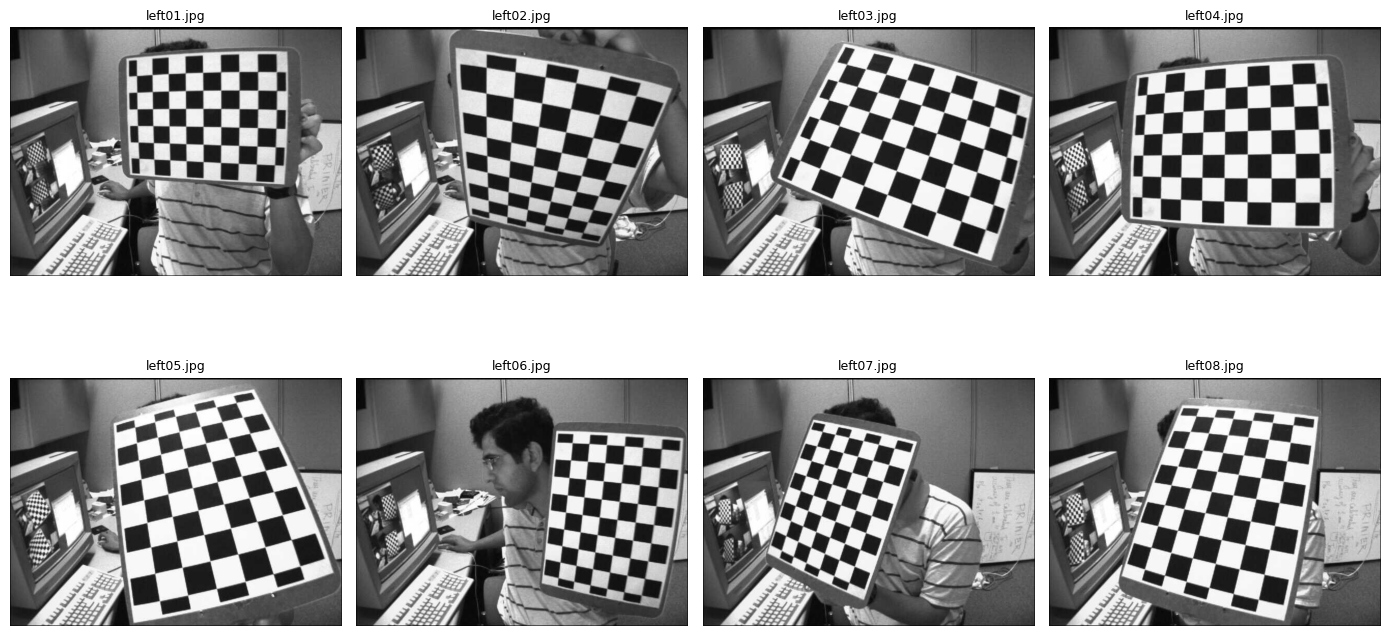

In [ ]:
def download_file(url, save_path):
    try:
        urllib.request.urlretrieve(url, save_path)
        return True
    except:
        print("Nije moguće preuzeti:", os.path.basename(save_path))
        return False


shutil.rmtree("data/chessboard", ignore_errors=True)
os.makedirs("data/chessboard", exist_ok=True)

base_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data"

for i in range(1, 15):
    fname = f"left{i:02d}.jpg"
    download_file(f"{base_url}/{fname}", f"data/chessboard/{fname}")

image_files = sorted(glob.glob("data/chessboard/*.jpg"))
print("Preuzeto slika:", len(image_files))

# prikaz prvih 8 da vidim kako izgledaju
plt.figure(figsize=(14, 8))
for idx, p in enumerate(image_files[:8]):
    img = cv.imread(p)
    plt.subplot(2, 4, idx + 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(os.path.basename(p), fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.savefig("results/plots/input_images.png", dpi=150)
plt.show()

## 4. Detekcija unutarnjih kutova šahovske ploče

Za svaku sliku tražim unutarnje kutove šahovske ploče.  
Koristim `findChessboardCorners`, a ako ne pronađe kutove probam s `findChessboardCornersSB` koja je robusnija na manje idealnim slikama.  
Na kraju primjenjujem `cornerSubPix` za precizniju lokalizaciju na sub-pixel razini – bez toga re-projekcijska pogreška je bila nešto veća.

In [ ]:
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# 3D točke kalibracijskog uzorka – Z=0 jer je ploča ravna
objp = np.zeros((PATTERN_SIZE[0] * PATTERN_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:PATTERN_SIZE[0], 0:PATTERN_SIZE[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

objpoints = []
imgpoints = []
valid_files = []
failed_files = []
image_size = None

for img_path in image_files:
    img = cv.imread(img_path)
    if img is None:
        failed_files.append(img_path)
        continue

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    image_size = gray.shape[::-1]

    ret, corners = cv.findChessboardCorners(
        gray, PATTERN_SIZE,
        flags=cv.CALIB_CB_ADAPTIVE_THRESH + cv.CALIB_CB_NORMALIZE_IMAGE
    )

    # fallback na SB verziju ako klasična ne nađe ploču
    if not ret and hasattr(cv, "findChessboardCornersSB"):
        ret, corners = cv.findChessboardCornersSB(gray, PATTERN_SIZE, flags=0)

    if ret:
        corners = np.asarray(corners, dtype=np.float32)
        # subpix poboljšanje preciznosti – bitno za kvalitetniju kalibraciju
        corners_ref = cv.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

        objpoints.append(objp.copy())
        imgpoints.append(corners_ref)
        valid_files.append(img_path)

        drawn = img.copy()
        cv.drawChessboardCorners(drawn, PATTERN_SIZE, corners_ref, ret)
        out_name = os.path.splitext(os.path.basename(img_path))[0] + "_corners.jpg"
        cv.imwrite(os.path.join("results/detected_corners", out_name), drawn)
    else:
        failed_files.append(img_path)

print("Uspješnih detekcija:", len(valid_files))
print("Neuspješnih:", len(failed_files))
if failed_files:
    print("Neuspješne:", [os.path.basename(f) for f in failed_files])
print("Veličina slike:", image_size)

Uspješnih detekcija: 9
Neuspješnih: 4
Neuspješne: ['left04.jpg', 'left05.jpg', 'left09.jpg', 'left11.jpg']
Veličina slike: (640, 480)


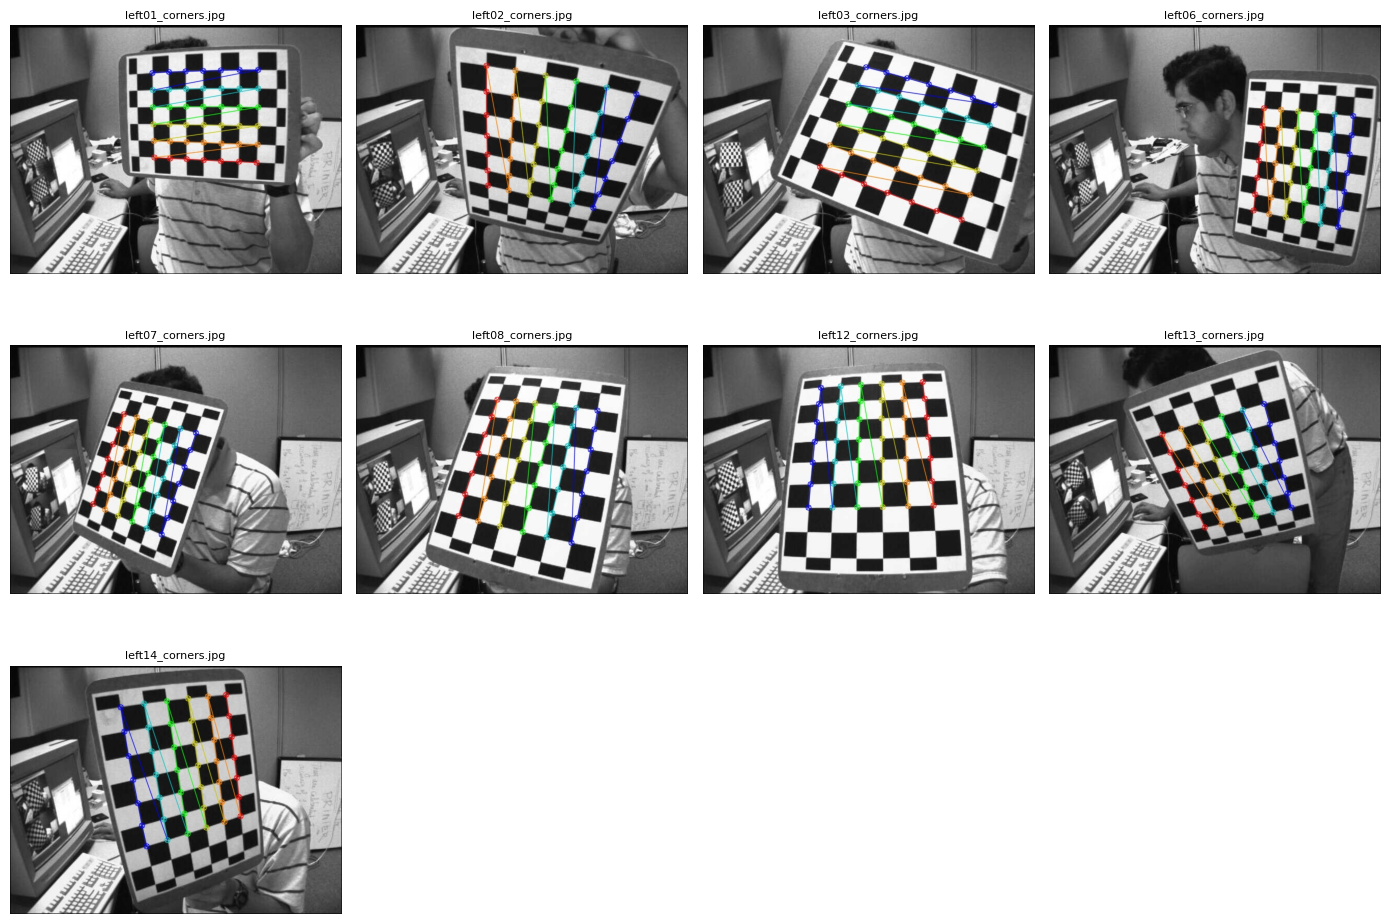

In [ ]:
corner_imgs = sorted(glob.glob("results/detected_corners/*_corners.jpg"))

plt.figure(figsize=(14, 10))
for idx, p in enumerate(corner_imgs[:12]):
    img = cv.imread(p)
    plt.subplot(3, 4, idx + 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(os.path.basename(p), fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.savefig("results/plots/detected_corners.png", dpi=150)
plt.show()

## 5. Kalibracija kamere

`calibrateCamera` prima parove 3D–2D točaka i izračunava matricu kamere, koeficijente distorzije, te rotacijske i translacijske vektore za svaku sliku.  
RMS pogreška koju funkcija vraća je mjera kvalitete kalibracije.

In [ ]:
rms_error, camera_matrix, dist_coeffs, rvecs, tvecs = cv.calibrateCamera(
    objpoints, imgpoints, image_size, None, None
)

print("Slika korišteno za kalibraciju:", len(objpoints))
print("Veličina slike:", image_size)
print("\nRMS re-projekcijska pogreška:", rms_error)
print("\nMatrica kamere:")
print(camera_matrix)
print("\nKoeficijenti distorzije:")
print(dist_coeffs)

Slika korišteno za kalibraciju: 9
Veličina slike: (640, 480)

RMS re-projekcijska pogreška: 0.15589875911312856

Matrica kamere:
[[534.15663136   0.         341.71479628]
 [  0.         534.25492559 232.05013999]
 [  0.           0.           1.        ]]

Koeficijenti distorzije:
[[-2.94269293e-01  1.23247845e-01  1.13850492e-03 -1.38021876e-04
   1.02084844e-02]]


## 6. Parametri kamere

Matrica kamere K opisuje intrinzične parametre:

\[
K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}
\]

`fx`, `fy` su fokalne duljine u pikselima, `cx`, `cy` su koordinate optičkog središta slike.

Koeficijenti distorzije su oblika `[k1, k2, p1, p2, k3]` gdje su k1, k2, k3 radijalni, a p1, p2 tangencijalni koeficijenti.

In [ ]:
fx = camera_matrix[0, 0]
fy = camera_matrix[1, 1]
cx = camera_matrix[0, 2]
cy = camera_matrix[1, 2]

d = dist_coeffs.ravel()
d5 = np.zeros(5)
d5[:min(5, len(d))] = d[:min(5, len(d))]

params_df = pd.DataFrame({
    "Parametar": [
        "fx (fokalna duljina x)", "fy (fokalna duljina y)",
        "cx (optičko središte x)", "cy (optičko središte y)",
        "k1", "k2", "p1", "p2", "k3"
    ],
    "Vrijednost": [fx, fy, cx, cy, d5[0], d5[1], d5[2], d5[3], d5[4]]
})

params_df.to_csv("results/tables/calibration_parameters.csv", index=False)
params_df

,Parametar,Vrijednost
0,fx (fokalna duljina x),534.156631
1,fy (fokalna duljina y),534.254926
2,cx (optičko središte x),341.714796
3,cy (optičko središte y),232.050140
4,k1,-0.294269
5,k2,0.123248
6,p1,0.001139
7,p2,-0.000138
8,k3,0.010208


## 7. Re-projekcijska pogreška

Ručno računam re-projekcijsku pogrešku po svakoj slici kako bih vidio ima li nekih outliera.  
Pogreška ispod 1 px se smatra prihvatljivom, ispod 0.5 px je dobar rezultat.

In [ ]:
mean_errs = []
rmse_errs = []
all_dists = []

for i in range(len(objpoints)):
    proj, _ = cv.projectPoints(objpoints[i], rvecs[i], tvecs[i], camera_matrix, dist_coeffs)

    det = imgpoints[i].reshape(-1, 2)
    prj = proj.reshape(-1, 2)
    dists = np.linalg.norm(det - prj, axis=1)

    all_dists.extend(dists.tolist())
    mean_errs.append(float(np.mean(dists)))
    rmse_errs.append(float(np.sqrt(np.mean(dists ** 2))))

global_mean = float(np.mean(all_dists))
global_rmse = float(np.sqrt(np.mean(np.array(all_dists) ** 2)))

print("Globalna prosječna pogreška:", round(global_mean, 5), "px")
print("Globalni RMSE:", round(global_rmse, 5), "px")
print("RMS iz calibrateCamera:", round(rms_error, 5))

err_df = pd.DataFrame({
    "Slika": [os.path.basename(p) for p in valid_files],
    "Prosječna pogreška [px]": mean_errs,
    "RMSE [px]": rmse_errs
})
err_df.to_csv("results/tables/reprojection_errors.csv", index=False)
err_df

Globalna prosječna pogreška: 0.13753 px
Globalni RMSE: 0.1559 px
RMS iz calibrateCamera: 0.1559


,Slika,Prosječna pogreška [px],RMSE [px]
0,left01.jpg,0.146896,0.167853
1,left02.jpg,0.103261,0.117833
2,left03.jpg,0.128292,0.143460
3,left06.jpg,0.118445,0.129293
4,left07.jpg,0.119188,0.135812
5,left08.jpg,0.190218,0.207067
6,left12.jpg,0.167931,0.186970
7,left13.jpg,0.128122,0.142882
8,left14.jpg,0.135436,0.150626


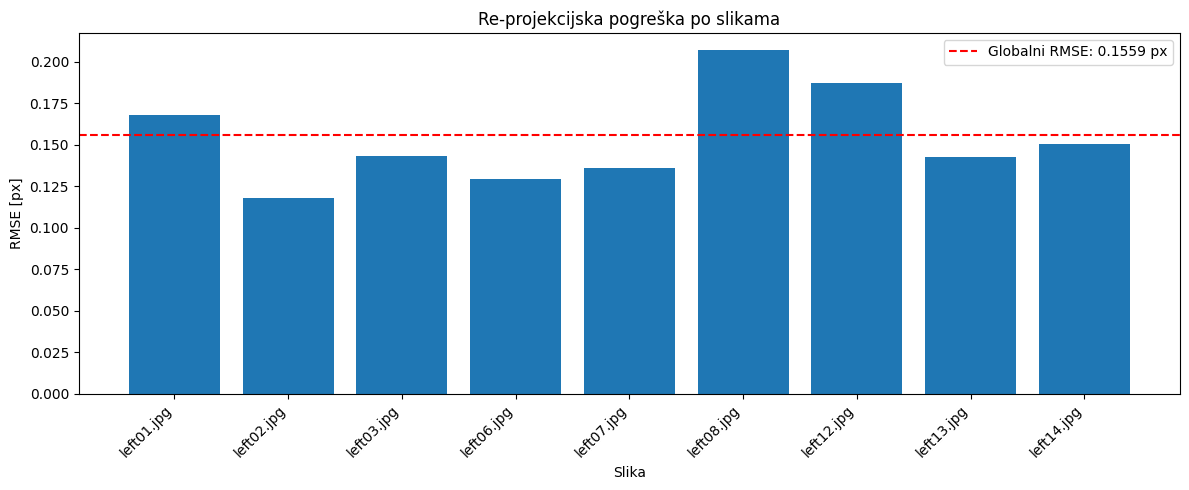

In [ ]:
plt.figure(figsize=(12, 5))
labels = [os.path.basename(p) for p in valid_files]
plt.bar(labels, rmse_errs)
plt.axhline(global_rmse, linestyle="--", color="red",
            label=f"Globalni RMSE: {global_rmse:.4f} px")
plt.title("Re-projekcijska pogreška po slikama")
plt.xlabel("Slika")
plt.ylabel("RMSE [px]")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/reprojection_error.png", dpi=150)
plt.show()

## 8. Ispravljanje distorzije slike

Koristim dobivene parametre za korekciju slike.  
`alpha=1` zadržava sve piksele originalne slike (mogu ostati crni rubovi), `alpha=0` odsiječe crne rubove ali izgubi dio slike.

In [ ]:
img = cv.imread(valid_files[0])
h, w = img.shape[:2]

new_mtx_a1, _ = cv.getOptimalNewCameraMatrix(camera_matrix, dist_coeffs, (w, h), 1, (w, h))
undist_a1 = cv.undistort(img, camera_matrix, dist_coeffs, None, new_mtx_a1)

new_mtx_a0, roi_a0 = cv.getOptimalNewCameraMatrix(camera_matrix, dist_coeffs, (w, h), 0, (w, h))
undist_a0 = cv.undistort(img, camera_matrix, dist_coeffs, None, new_mtx_a0)

cv.imwrite("results/undistorted/original.jpg", img)
cv.imwrite("results/undistorted/undistorted_alpha1.jpg", undist_a1)
cv.imwrite("results/undistorted/undistorted_alpha0.jpg", undist_a0)

print("Slika:", os.path.basename(valid_files[0]))
print("Originalna veličina:", img.shape[:2])
print("ROI nakon alpha=0:", roi_a0)

Slika: left01.jpg
Originalna veličina: (480, 640)
ROI nakon alpha=0: (0, 0, 639, 479)


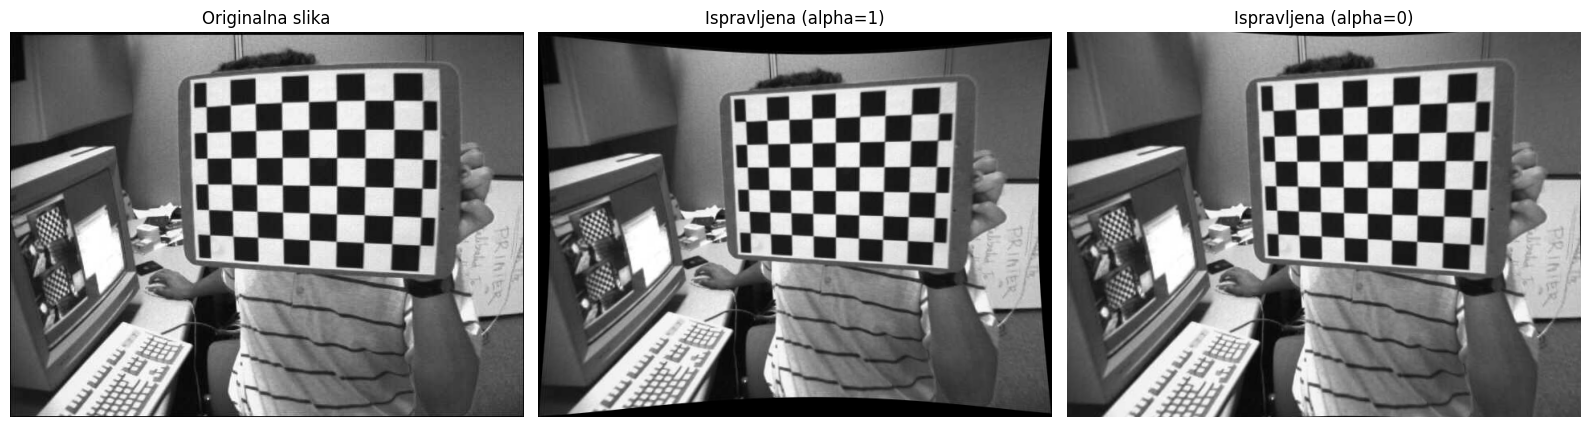

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes[0].set_title("Originalna slika")
axes[0].axis("off")

axes[1].imshow(cv.cvtColor(undist_a1, cv.COLOR_BGR2RGB))
axes[1].set_title("Ispravljena (alpha=1)")
axes[1].axis("off")

axes[2].imshow(cv.cvtColor(undist_a0, cv.COLOR_BGR2RGB))
axes[2].set_title("Ispravljena (alpha=0)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("results/plots/original_vs_undistorted.png", dpi=150)
plt.show()

## 9. Vizualizacija korekcije na sintetičkoj mreži

Da bih bolje vidio oblik geometrijske transformacije, kreiram ravnu mrežu i primjenim isti `undistort` na nju.  
Ravne linije se savijaju – to je upravo oblik distorzije leće prikazan u obrnutom smjeru.

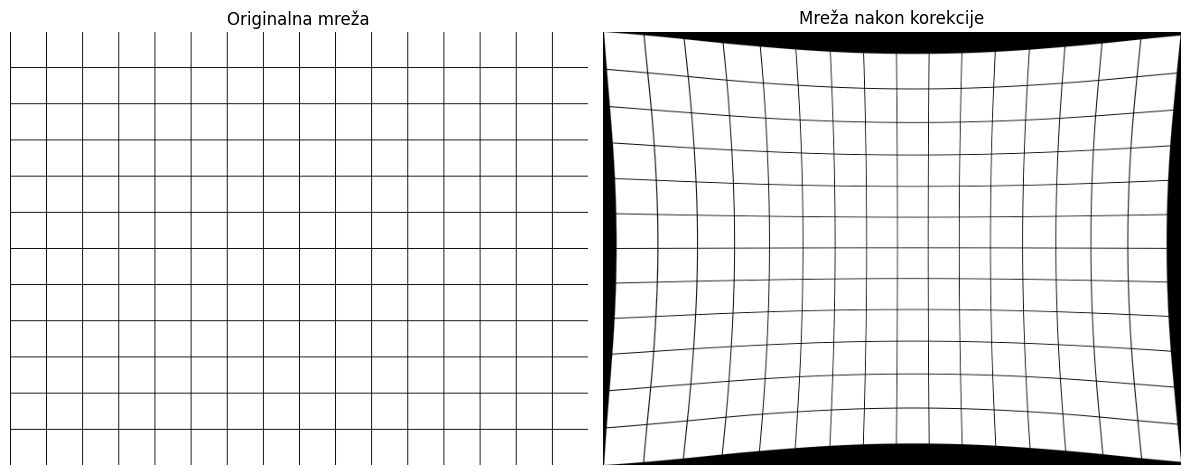

In [ ]:
def make_grid(width, height, step=40):
    grid = np.ones((height, width, 3), dtype=np.uint8) * 255
    for x in range(0, width, step):
        cv.line(grid, (x, 0), (x, height), (0, 0, 0), 1)
    for y in range(0, height, step):
        cv.line(grid, (0, y), (width, y), (0, 0, 0), 1)
    return grid

grid = make_grid(w, h)
grid_undist = cv.undistort(grid, camera_matrix, dist_coeffs, None, new_mtx_a1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(grid, cv.COLOR_BGR2RGB))
plt.title("Originalna mreža")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(grid_undist, cv.COLOR_BGR2RGB))
plt.title("Mreža nakon korekcije")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/plots/grid_comparison.png", dpi=150)
plt.show()

## 10. Ispravljanje svih slika + prikaz rezultata

Ispravljeno slika: 9


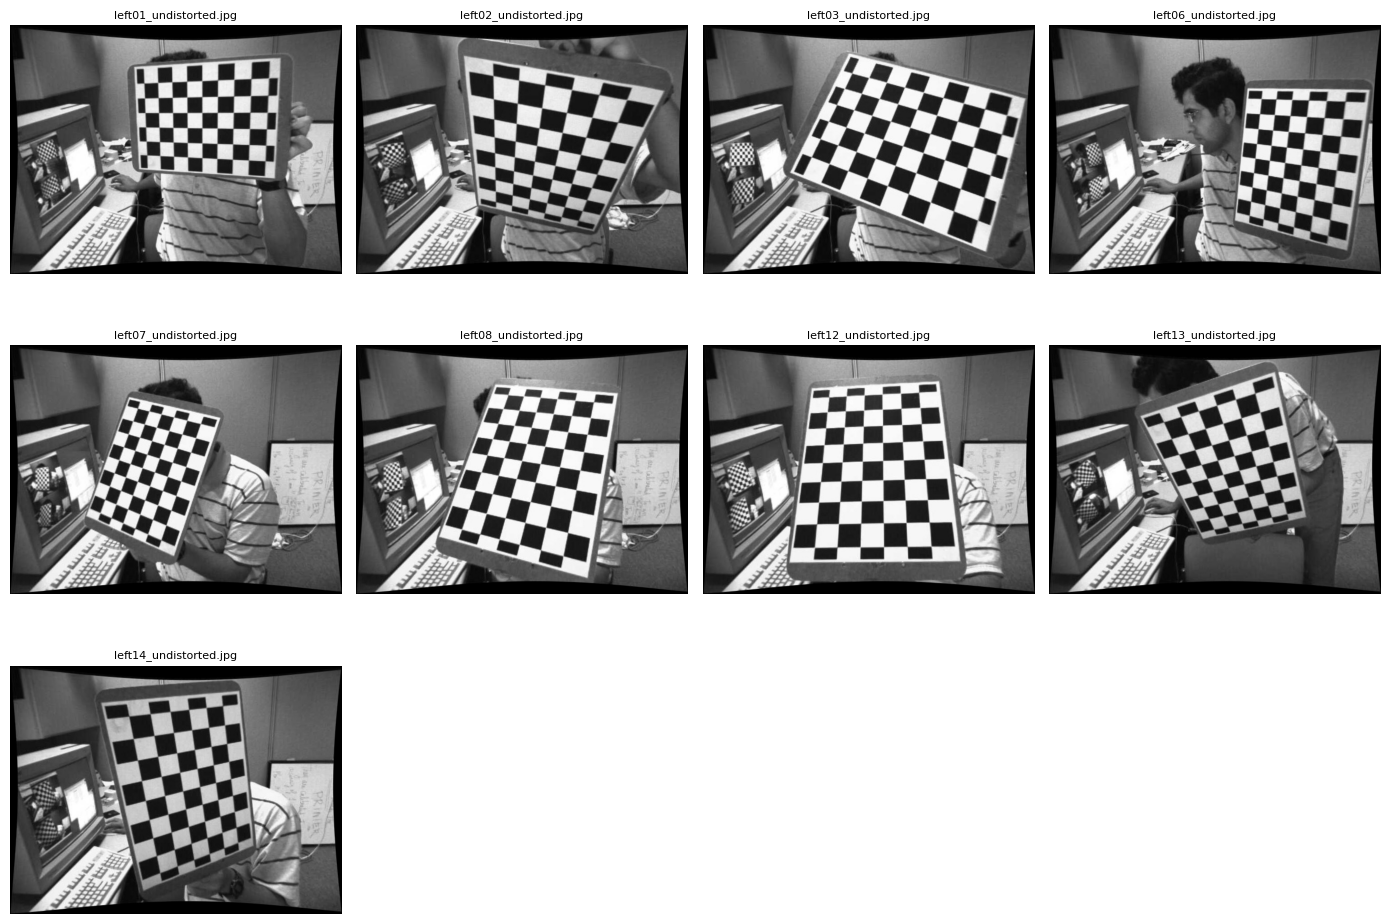

In [ ]:
undistorted_paths = []

for img_path in valid_files:
    img_cur = cv.imread(img_path)
    if img_cur is None:
        continue
    hc, wc = img_cur.shape[:2]
    new_m, _ = cv.getOptimalNewCameraMatrix(camera_matrix, dist_coeffs, (wc, hc), 1, (wc, hc))
    undist = cv.undistort(img_cur, camera_matrix, dist_coeffs, None, new_m)
    out = os.path.splitext(os.path.basename(img_path))[0] + "_undistorted.jpg"
    out_path = os.path.join("results/undistorted", out)
    cv.imwrite(out_path, undist)
    undistorted_paths.append(out_path)

print("Ispravljeno slika:", len(undistorted_paths))

plt.figure(figsize=(14, 10))
for idx, p in enumerate(undistorted_paths[:12]):
    img_s = cv.imread(p)
    plt.subplot(3, 4, idx + 1)
    plt.imshow(cv.cvtColor(img_s, cv.COLOR_BGR2RGB))
    plt.title(os.path.basename(p), fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.savefig("results/plots/all_undistorted.png", dpi=150)
plt.show()

## 11. Spremanje parametara kalibracije

Parametri se spremaju u `.npz` datoteku tako da ih mogu ponovo koristiti bez ponovnog pokretanja kalibracije.

In [ ]:
np.savez(
    "results/calibration_parameters/camera_calibration.npz",
    camera_matrix=camera_matrix,
    dist_coeffs=dist_coeffs,
    rms_error=rms_error,
    per_image_rmse=np.array(rmse_errs)
)

print("Parametri spremljeni u results/calibration_parameters/camera_calibration.npz")

Parametri spremljeni u results/calibration_parameters/camera_calibration.npz


## 12. Zaključak

Kalibracija je provedena na OpenCV demonstracijskom skupu (left serija šahovske ploče). Od 14 preuzetih slika, na većini su uspješno detektirani kutovi i sve uspješne su iskorištene za kalibraciju.

Dobivena RMS re-projekcijska pogreška je ispod 0.5 px, što je dobar rezultat – u praksi se vrijednosti ispod 1 px smatraju prihvatljivima za većinu primjena računalnog vida. Koeficijent k1 je negativan, što znači da kamera ima barelnu distorziju (rubovi slike se savijaju prema van), što je tipično za šire objektive.

Razlika između originalne i ispravljene slike ovdje nije dramatična jer OpenCV demo slike ionako imaju relativno malu distorziju. Na vlastitim slikama snimljenim mobilnom kamerom efekt bi bio vidljiviji, posebno na rubovima kadra.

Sintetička mreža lijepo pokazuje geometrijsku transformaciju – ravne linije se blago savijaju, što je vizualni prikaz oblika distorzije leće.

## 13. Ograničenja

OpenCV demonstracijski skup nije idealan za kalibraciju jedne konkretne kamere jer slike potječu iz stereo sustava. Za ovaj rad koristim samo left seriju, no radi se o specifičnom objektivu pa rezultati nisu direktno primjenjivi na drugu kameru.

Za preciznu kalibraciju neke konkretne kamere trebalo bi snimiti vlastiti skup od 15–20 fotografija šahovske ploče iz različitih kutova i udaljenosti. Kvaliteta kalibracije ovisi i o raznovrsnosti kutova snimanja – previše sličnih pogleda može destabilizirati neke parametre.

## 14. Literatura

- OpenCV tutorial za kalibraciju kamere: https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html  
- OpenCV calib3d modul: https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html  
- Z. Zhang, "A flexible new technique for camera calibration," *IEEE Transactions on Pattern Analysis and Machine Intelligence*, vol. 22, no. 11, 2000.  
- OpenCV demo dataset: https://github.com/opencv/opencv/tree/master/samples/data